# Machine Learning Engineer Nanodegree
## Supervised Learning
## Project: Building a Student Intervention System

### Data

The dataset used in this project is included as `student-data.csv`. This dataset has the following attributes:

- `school` : student's school (binary: "GP" or "MS")
- `sex` : student's sex (binary: "F" - female or "M" - male)
- `age` : student's age (numeric: from 15 to 22)
- `address` : student's home address type (binary: "U" - urban or "R" - rural)
- `famsize` : family size (binary: "LE3" - less or equal to 3 or "GT3" - greater than 3)
- `Pstatus` : parent's cohabitation status (binary: "T" - living together or "A" - apart)
- `Medu` : mother's education (numeric: 0 - none,  1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4 - higher education)
- `Fedu` : father's education (numeric: 0 - none,  1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4 - higher education)
- `Mjob` : mother's job (nominal: "teacher", "health" care related, civil "services" (e.g. administrative or police), "at_home" or "other")
- `Fjob` : father's job (nominal: "teacher", "health" care related, civil "services" (e.g. administrative or police), "at_home" or "other")
- `reason` : reason to choose this school (nominal: close to "home", school "reputation", "course" preference or "other")
- `guardian` : student's guardian (nominal: "mother", "father" or "other")
- `traveltime` : home to school travel time (numeric: 1 - <15 min., 2 - 15 to 30 min., 3 - 30 min. to 1 hour, or 4 - >1 hour)
- `studytime` : weekly study time (numeric: 1 - <2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours)
- `failures` : number of past class failures (numeric: n if 1<=n<3, else 4)
- `schoolsup` : extra educational support (binary: yes or no)
- `famsup` : family educational support (binary: yes or no)
- `paid` : extra paid classes within the course subject (Math or Portuguese) (binary: yes or no)
- `activities` : extra-curricular activities (binary: yes or no)
- `nursery` : attended nursery school (binary: yes or no)
- `higher` : wants to take higher education (binary: yes or no)
- `internet` : Internet access at home (binary: yes or no)
- `romantic` : with a romantic relationship (binary: yes or no)
- `famrel` : quality of family relationships (numeric: from 1 - very bad to 5 - excellent)
- `freetime` : free time after school (numeric: from 1 - very low to 5 - very high)
- `goout` : going out with friends (numeric: from 1 - very low to 5 - very high)
- `Dalc` : workday alcohol consumption (numeric: from 1 - very low to 5 - very high)
- `Walc` : weekend alcohol consumption (numeric: from 1 - very low to 5 - very high)
- `health` : current health status (numeric: from 1 - very bad to 5 - very good)
- `absences` : number of school absences (numeric: from 0 to 93)
- `passed` : did the student pass the final exam (binary: yes or no)

Welcome to the second project of the Machine Learning Engineer Nanodegree! In this notebook, some template code has already been provided for you, and it will be your job to implement the additional functionality necessary to successfully complete this project. Sections that begin with **'Implementation'** in the header indicate that the following block of code will require additional functionality which you must provide. Instructions will be provided for each section and the specifics of the implementation are marked in the code block with a `'TODO'` statement. Please be sure to read the instructions carefully!

In addition to implementing code, there will be questions that you must answer which relate to the project and your implementation. Each section where you will answer a question is preceded by a **'Question X'** header. Carefully read each question and provide thorough answers in the following text boxes that begin with **'Answer:'**. Your project submission will be evaluated based on your answers to each of the questions and the implementation you provide.  

>**Note:** Code and Markdown cells can be executed using the **Shift + Enter** keyboard shortcut. In addition, Markdown cells can be edited by typically double-clicking the cell to enter edit mode.

### Question 1 - Classification vs. Regression
*Your goal for this project is to identify students who might need early intervention before they fail to graduate. Which type of supervised learning problem is this, classification or regression? Why?*

**Answer: **

This is a supervised classification problem because the required output ('passed': likelihood that a given student will pass) is a discrete value (binary: yes or no).

## Exploring the Data
Run the code cell below to load necessary Python libraries and load the student data. Note that the last column from this dataset, `'passed'`, will be our target label (whether the student graduated or didn't graduate). All other columns are features about each student.

In [1]:
# Import libraries
import numpy as np
import pandas as pd
from time import time
from sklearn.metrics import f1_score

# Read student data
student_data = pd.read_csv("student-data.csv")
print "Student data read successfully!"

Student data read successfully!


### Implementation: Data Exploration
Let's begin by investigating the dataset to determine how many students we have information on, and learn about the graduation rate among these students. In the code cell below, you will need to compute the following:
- The total number of students, `n_students`.
- The total number of features for each student, `n_features`.
- The number of those students who passed, `n_passed`.
- The number of those students who failed, `n_failed`.
- The graduation rate of the class, `grad_rate`, in percent (%).


In [2]:
# TODO: Calculate number of students
n_students = student_data.shape[0]

# TODO: Calculate number of features
n_features = len(student_data.columns[:-1])

# TODO: Calculate passing students
n_passed = student_data[student_data.passed == 'yes'].shape[0]

# TODO: Calculate failing students
n_failed = student_data[student_data.passed == 'no'].shape[0]

# TODO: Calculate graduation rate
grad_rate = (float(n_passed) / float(n_students)) * 100

# Print the results
print "Total number of students: {}".format(n_students)
print "Number of features: {}".format(n_features)
print "Number of students who passed: {}".format(n_passed)
print "Number of students who failed: {}".format(n_failed)
print "Graduation rate of the class: {:.2f}%".format(grad_rate)

Total number of students: 395
Number of features: 30
Number of students who passed: 265
Number of students who failed: 130
Graduation rate of the class: 67.09%


In [3]:
student_data.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000


## Preparing the Data
In this section, we will prepare the data for modeling, training and testing.

### Identify feature and target columns
It is often the case that the data you obtain contains non-numeric features. This can be a problem, as most machine learning algorithms expect numeric data to perform computations with.

Run the code cell below to separate the student data into feature and target columns to see if any features are non-numeric.

In [3]:
# Extract feature columns
feature_cols = list(student_data.columns[:-1])

# Extract target column 'passed'
target_col = student_data.columns[-1] 

# Show the list of columns
print "Feature columns:\n{}".format(feature_cols)
print "\nTarget column: {}".format(target_col)

# Separate the data into feature data and target data (X_all and y_all, respectively)
X_all = student_data[feature_cols]
y_all = student_data[target_col]

# Show the feature information by printing the first five rows
print "\nFeature values:"
print X_all.head()

Feature columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

Target column: passed

Feature values:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher   
1     GP   F   17       U     GT3       T     1     1  at_home     other   
2     GP   F   15       U     LE3       T     1     1  at_home     other   
3     GP   F   15       U     GT3       T     4     2   health  services   
4     GP   F   16       U     GT3       T     3     3    other     other   

    ...    higher internet  romantic  famrel  freetime goout Dalc Walc health  \
0   ...       yes       no        no       4         3     4    1    1      3   
1   ...       

### Preprocess Feature Columns

As you can see, there are several non-numeric columns that need to be converted! Many of them are simply `yes`/`no`, e.g. `internet`. These can be reasonably converted into `1`/`0` (binary) values.

Other columns, like `Mjob` and `Fjob`, have more than two values, and are known as _categorical variables_. The recommended way to handle such a column is to create as many columns as possible values (e.g. `Fjob_teacher`, `Fjob_other`, `Fjob_services`, etc.), and assign a `1` to one of them and `0` to all others.

These generated columns are sometimes called _dummy variables_, and we will use the [`pandas.get_dummies()`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.get_dummies.html?highlight=get_dummies#pandas.get_dummies) function to perform this transformation. Run the code cell below to perform the preprocessing routine discussed in this section.

In [4]:
def preprocess_features(X):
    ''' Preprocesses the student data and converts non-numeric binary variables into
        binary (0/1) variables. Converts categorical variables into dummy variables. '''
    
    # Initialize new output DataFrame
    output = pd.DataFrame(index = X.index)

    # Investigate each feature column for the data
    for col, col_data in X.iteritems():
        
        # If data type is non-numeric, replace all yes/no values with 1/0
        if col_data.dtype == object:
            col_data = col_data.replace(['yes', 'no'], [1., 0.])

        # If data type is categorical, convert to dummy variables
        if col_data.dtype == object:
            # Example: 'school' => 'school_GP' and 'school_MS'
            col_data = pd.get_dummies(col_data, prefix = col)  
        
        # Collect the revised columns
        output = output.join(col_data)
    
    return output

X_all = preprocess_features(X_all)
print "Processed feature columns ({} total features):\n{}".format(len(X_all.columns), list(X_all.columns))

# Show the feature information by printing the first five rows
print X_all.head()

Processed feature columns (48 total features):
['school_GP', 'school_MS', 'sex_F', 'sex_M', 'age', 'address_R', 'address_U', 'famsize_GT3', 'famsize_LE3', 'Pstatus_A', 'Pstatus_T', 'Medu', 'Fedu', 'Mjob_at_home', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_at_home', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_course', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_father', 'guardian_mother', 'guardian_other', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
   school_GP  school_MS  sex_F  sex_M  age  address_R  address_U  famsize_GT3  \
0        1.0        0.0    1.0    0.0   18        0.0        1.0          1.0   
1        1.0        0.0    1.0    0.0   17        0.0        1.0          1.0   
2        1.0        0.0    1.0    0.0   15        0.0        1.0          0.0   


### Exploratory data analysis (EDA)

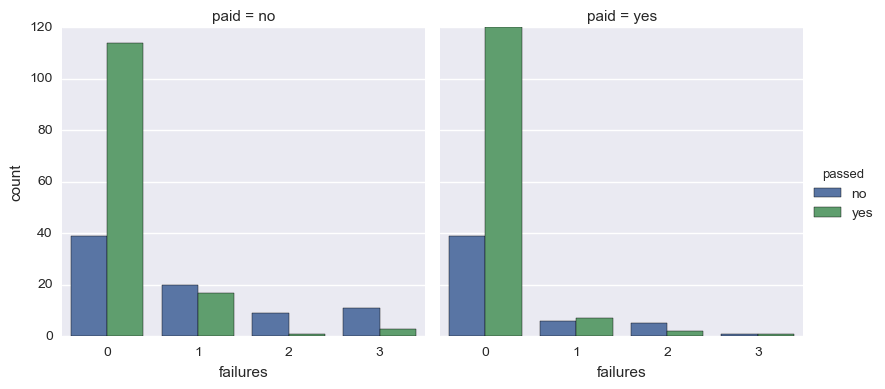

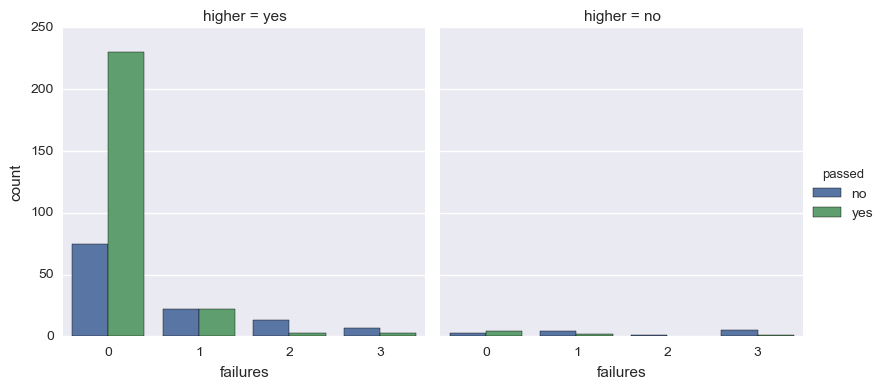

In [14]:
%matplotlib inline
import seaborn as sns
sns.factorplot("failures", col="paid", data=student_data, hue='passed', 
               kind="count");
sns.factorplot("failures", col="higher", data=student_data, hue='passed', 
               kind="count");

### Implementation: Training and Testing Data Split
So far, we have converted all _categorical_ features into numeric values. For the next step, we split the data (both features and corresponding labels) into training and test sets. In the following code cell below, you will need to implement the following:
- Randomly shuffle and split the data (`X_all`, `y_all`) into training and testing subsets.
  - Use 300 training points (approximately 75%) and 95 testing points (approximately 25%).
  - Set a `random_state` for the function(s) you use, if provided.
  - Store the results in `X_train`, `X_test`, `y_train`, and `y_test`.

In [5]:
# TODO: Import any additional functionality you may need here
from sklearn.model_selection import train_test_split

# TODO: Set the number of training points
num_train = 300

# Set the number of testing points
num_test = X_all.shape[0] - num_train

# TODO: Shuffle and split the dataset into the number of training and testing points above
X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=num_test, random_state=2
    )

# Show the results of the split
print "Training set has {} samples.".format(X_train.shape[0])
print "Testing set has {} samples.".format(X_test.shape[0])

Training set has 300 samples.
Testing set has 95 samples.


## Training and Evaluating Models
In this section, you will choose 3 supervised learning models that are appropriate for this problem and available in `scikit-learn`. You will first discuss the reasoning behind choosing these three models by considering what you know about the data and each model's strengths and weaknesses. You will then fit the model to varying sizes of training data (100 data points, 200 data points, and 300 data points) and measure the F<sub>1</sub> score. You will need to produce three tables (one for each model) that shows the training set size, training time, prediction time, F<sub>1</sub> score on the training set, and F<sub>1</sub> score on the testing set.

**The following supervised learning models are currently available in** [`scikit-learn`](http://scikit-learn.org/stable/supervised_learning.html) **that you may choose from:**
- Gaussian Naive Bayes (GaussianNB)
- Decision Trees
- Ensemble Methods (Bagging, AdaBoost, Random Forest, Gradient Boosting)
- K-Nearest Neighbors (KNeighbors)
- Stochastic Gradient Descent (SGDC)
- Support Vector Machines (SVM)
- Logistic Regression

### Question 2 - Model Application
*List three supervised learning models that are appropriate for this problem. For each model chosen*
- Describe one real-world application in industry where the model can be applied. *(You may need to do a small bit of research for this — give references!)* 
- What are the strengths of the model; when does it perform well? 
- What are the weaknesses of the model; when does it perform poorly?
- What makes this model a good candidate for the problem, given what you know about the data?

** Guides on finding the rigth estimator** 

Microsoft Machine Learning Algorithm Cheat Sheet: 
![Machine Learning Algorithm Cheat Sheet](https://docs.microsoft.com/es-es/azure/machine-learning/media/machine-learning-algorithm-cheat-sheet/machine-learning-algorithm-cheat-sheet-small_v_0_6-01.png)

scikit-learn algorithm cheat-sheet: 
![scikit-learn algorithm cheat-sheet](http://scikit-learn.org/stable/_static/ml_map.png)

**Answer: **

**Supervised learning models: **

1. [Support Vector Machines (SVM)](http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html#sklearn.neighbors.NearestNeighbors)

2. [Gaussian Naive Bayes (GaussianNB)](http://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html#sklearn.naive_bayes.GaussianNB)

3. [K-Nearest Neighbors (KNeighbors)](http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html#sklearn.neighbors.NearestNeighbors)

**Performance measures: **
Classification accuracy alone is typically not enough information to make an inform decision. Therefore, the following performance measures will we use:
[Confusion Matrix](http://en.wikipedia.org/wiki/Table_of_confusion#Table_of_confusion): clean way to present the prediction results of a classifier.
[Precision](https://en.wikipedia.org/wiki/Information_retrieval#Precision): Precision can be thought of as a measure of a classifier's exactness. A low precision can also indicate a large number of False Positives.
[Recall](http://en.wikipedia.org/wiki/Information_retrieval#Recall): Recall can be thought of as a measure of a classifier's completeness. A low recall indicates many False Negatives.
[F1 Score](http://en.wikipedia.org/wiki/F1_score): Armonic mean of precision and recall, conveys the balance between the precision and the recall.

**Getting familiar with the data: **

* Total number of students: 395

* Number of features: 30

* Number of students who passed: 265

* Number of students who failed: 130

* Graduation rate of the class: 67.09%

* Processed feature columns: 48 total features

**Important observations: **

* Small dataset (395 students)

* Large number of features (48 features)

* Very low graduation rate of the class (67.09%)

Because our training set is small, high bias/low variance classifiers (e.g., Naive Bayes) have an advantage over low bias/high variance classifiers (e.g., kNN), but high bias classifiers aren’t powerful enough to provide accurate models.

**Support Vector Machines (SVM): **

1. Histogram of Oriented Gradients (HOG) image descriptor and a Linear Support Vector Machine (SVM) could be used to train highly accurate object classifiers [1]. HOG is a feature descriptos that counts occurrences of gradient orientation in localized portions of an image. HOG descriptors are extracted  from P positive samples from the training data with the object(s) you want to detect and from N negative samples from a negative training set that does not contain any of the objects you want to detect (N >> P). Linear Support Vector Machine is trained on the positive and negative samples. The sliding window technique is applied to each image and each possible scale of each image. HOG descriptors are calculated at each window and the classifier applied. The feature vector associated with the false-positive is recorded  along with the probability of the classification. This false-positive samples are sorted by their confidence (i.e. probability) and the classifier re-trained. Now the classifier can be applied to the test data set and detect an object if there is a sufficiently large probability. Further work shows ensemble can be applied also [2]. 
  
2. Strengths:
  * high accuracy
  * guarantees regarding overfitting
  * versatile: with an appropriate kernel they can work well even if the data isn’t linearly separable
    
3. Weaknesses:
  * memory-intensive
  * not well on large data sets training_time = $(size) ^ 3$
  * hard to interpret
  * not well if there is a lot of noise
  * If the number of features is much greater than the number of samples, the method is likely to give poor performances.
  
4. Overfitting in this small dataset with large number of features can be prevented tunning the parameter C.

[1]: http://lear.inrialpes.fr/people/triggs/pubs/Dalal-cvpr05.pdf "Histograms of Oriented Gradients for Human Detection"

[2]: http://www.cs.cmu.edu/~tmalisie/projects/iccv11/exemplarsvm-iccv11.pdf "Ensemble of Exemplar-SVMs for Object Detection and Beyond"


**Gaussian Naive Bayes (GaussianNB): **

1. Learning to Decode Cognitive States from Brain Images [3]: 
Magnetic Resonance Imaging (fMRI) can produce a three-dimensional image related to the human subject’s brain activity every half second. Gaussian Naive Bayes are then used for classifying the cognitive state of a human subject based on fRMIdata observed over a single time interval.

>"Our comparison of classifiers indicates that Gaussian Naive Bayes (GNB) and linear Support Vector Machine (SVM) classifiers outperform kNearest Neighbor across all threestudies, and that feature selection methods consistently improve classification error in all three studies. In comparing GNB to SVM, we found trends consistent with the observationsin Ng and Jordan (2002), that the relative performance of generative versus discriminative classifiers depends in a predictable fashion on the number of training examples and datadimension. In particular, our experiments are consistent with the hypothesis that the accuracy of SVM’s increases relatively more quickly than the accuracy of GNB as the data dimension is reduced via feature selection, and as the number of training examples increases."
 
2. Strengths:
  * simple
  * fast
  * will converge quicker than discriminative models like logistic regression if the conditional independence assumptions holds.
  * good for data sets with several features
    
3. Weaknesses:
  * it can’t learn interactions between features
  * bad estimator
  
4. Due to its simplicity, this algorithm might outperform more complex models when the data set isn’t large enough.

[3]: http://repository.cmu.edu/cgi/viewcontent.cgi?article=2091&context=psychology "Learning to Decode Cognitive States from Brain Images"

**K-Nearest Neighbors (KNeighbors): **

1. Predicting Economic Events [4]. 

Economic forecasting to predict economic events like financial crisis. Few  studies have used nonparametric methods. Recent studies demonstrate this method is more capable than other methods.

2. Strengths:
  * robust to noisy training data
  * effective if the training data is large
  * very flexible because it does not assume that the data fits a specific model
    
3. Weaknesses:
  * need to determine value of parameter K (number of nearest neighbors)
  * computation cost is quite high because we need to compute distance of each query instance to all training samples. Some indexing (e.g. K-D tree) may reduce this computational cost
  
4. It is robust for noisy data and with K-D tree indexing the computational cost may be reduce.

[4]: http://www.ijera.com/papers/Vol3_issue5/DI35605610.pdf "Application    of    K-Nearest    Neighbor    (KNN)    Approach    for Predicting Economic Events: Theoretical Background"

### Setup
Run the code cell below to initialize three helper functions which you can use for training and testing the three supervised learning models you've chosen above. The functions are as follows:
- `train_classifier` - takes as input a classifier and training data and fits the classifier to the data.
- `predict_labels` - takes as input a fit classifier, features, and a target labeling and makes predictions using the F<sub>1</sub> score.
- `train_predict` - takes as input a classifier, and the training and testing data, and performs `train_clasifier` and `predict_labels`.
 - This function will report the F<sub>1</sub> score for both the training and testing data separately.

In [6]:
def train_classifier(clf, X_train, y_train):
    ''' Fits a classifier to the training data. '''
    
    # Start the clock, train the classifier, then stop the clock
    start = time()
    clf.fit(X_train, y_train)
    end = time()
    
    # Print the results
    print "Trained model in {:.4f} seconds".format(end - start)
    
def predict_labels(clf, features, target):
    ''' Makes predictions using a fit classifier based on F1 score. '''
    
    # Start the clock, make predictions, then stop the clock
    start = time()
    y_pred = clf.predict(features)
    end = time()
    
    # Print and return results
    print "Made predictions in {:.4f} seconds.".format(end - start)
    return f1_score(target.values, y_pred, pos_label='yes')


def train_predict(clf, X_train, y_train, X_test, y_test):
    ''' Train and predict using a classifer based on F1 score. '''
    
    # Indicate the classifier and the training set size
    print "Training a {} using a training set size of {}. . .".format(clf.__class__.__name__, len(X_train))
    
    # Train the classifier
    train_classifier(clf, X_train, y_train)
    
    # Print the results of prediction for both training and testing
    print "F1 score for training set: {:.4f}.".format(predict_labels(clf, X_train, y_train))
    print "F1 score for test set: {:.4f}.\n".format(predict_labels(clf, X_test, y_test))

### Implementation: Model Performance Metrics
With the predefined functions above, you will now import the three supervised learning models of your choice and run the `train_predict` function for each one. Remember that you will need to train and predict on each classifier for three different training set sizes: 100, 200, and 300. Hence, you should expect to have 9 different outputs below — 3 for each model using the varying training set sizes. In the following code cell, you will need to implement the following:
- Import the three supervised learning models you've discussed in the previous section.
- Initialize the three models and store them in `clf_A`, `clf_B`, and `clf_C`.
 - Use a `random_state` for each model you use, if provided.
 - **Note:** Use the default settings for each model — you will tune one specific model in a later section.
- Create the different training set sizes to be used to train each model.
 - *Do not reshuffle and resplit the data! The new training points should be drawn from `X_train` and `y_train`.*
- Fit each model with each training set size and make predictions on the test set (9 in total).  
**Note:** Three tables are provided after the following code cell which can be used to store your results.

In [7]:
# TODO: Import the three supervised learning models from sklearn
from sklearn import svm
from sklearn.naive_bayes import GaussianNB
from sklearn import neighbors

# TODO: Initialize the three models
clf_A = svm.SVC(random_state=2)
clf_B = GaussianNB()
clf_C = neighbors.KNeighborsClassifier()

# TODO: Set up the training set sizes
X_train_100 = X_train.iloc[:100, :]
y_train_100 = y_train.iloc[:100]

X_train_200 = X_train.iloc[:200, :]
y_train_200 = y_train.iloc[:200]

X_train_300 = X_train.iloc[:300, :]
y_train_300 = y_train.iloc[:300]

# TODO: Execute the 'train_predict' function for each classifier and each training set size
# train_predict(clf, X_train, y_train, X_test, y_test)
for clf in [clf_A, clf_B, clf_C]:
    print "\n{}: \n".format(clf.__class__.__name__)
    train_predict(clf, X_train_100, y_train_100, X_test, y_test)
    train_predict(clf, X_train_200, y_train_200, X_test, y_test)
    train_predict(clf, X_train_300, y_train_300, X_test, y_test)


SVC: 

Training a SVC using a training set size of 100. . .
Trained model in 0.0180 seconds
Made predictions in 0.0037 seconds.
F1 score for training set: 0.8905.
Made predictions in 0.0018 seconds.
F1 score for test set: 0.8392.

Training a SVC using a training set size of 200. . .
Trained model in 0.0079 seconds
Made predictions in 0.0072 seconds.
F1 score for training set: 0.8620.
Made predictions in 0.0030 seconds.
F1 score for test set: 0.8267.

Training a SVC using a training set size of 300. . .
Trained model in 0.0169 seconds
Made predictions in 0.0130 seconds.
F1 score for training set: 0.8504.
Made predictions in 0.0041 seconds.
F1 score for test set: 0.8267.


GaussianNB: 

Training a GaussianNB using a training set size of 100. . .
Trained model in 0.0025 seconds
Made predictions in 0.0018 seconds.
F1 score for training set: 0.4103.
Made predictions in 0.0007 seconds.
F1 score for test set: 0.2955.

Training a GaussianNB using a training set size of 200. . .
Trained model 

### Tabular Results
Edit the cell below to see how a table can be designed in [Markdown](https://github.com/adam-p/markdown-here/wiki/Markdown-Cheatsheet#tables). You can record your results from above in the tables provided.

** Classifer 1 - SVC**  

| Training Set Size | Training Time | Prediction Time (test) | F1 Score (train) | F1 Score (test) |
| :---------------: | :---------------------: | :--------------------: | :--------------: | :-------------: |
| 100               |      0.0933            |         0.0027       |      0.8905      |     0.8392      |
| 200               |        0.0086          |         0.0060     |            0.8620      |           0.8267      |
| 300               |        0.0168          |        0.0122               |         0.8504         |    0.8267  |

** Classifer 2 - GaussianNB**  

| Training Set Size | Training Time | Prediction Time (test) | F1 Score (train) | F1 Score (test) |
| :---------------: | :---------------------: | :--------------------: | :--------------: | :-------------: |
| 100               |    0.0058       |       0.0054             |       0.4103           |    0.2955      |
| 200               |  0.0023             |    0.0010        |     0.3544    | 0.2651
| 300               |   0.0023    |   0.0017   |   0.7839  |    0.7692     |

** Classifer 3 - KNeighborsClassifier**  

| Training Set Size | Training Time | Prediction Time (test) | F1 Score (train) | F1 Score (test) |
| :---------------: | :---------------------: | :--------------------: | :--------------: | :-------------: |
| 100               |   0.0515     |       0.0363      |    0.7903  |   0.7385 |
| 200               |   0.0017   |     0.0087 |   0.7855   |    0.8116  |
| 300               |    0.0024   |       0.0159  |    0.8558  |  0.8143   |

### Learning curves for classifiers with default settings

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit
%matplotlib inline

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=1, train_sizes=np.linspace(.05, 1.0, 9), scoring=None):
    """
    Generate a simple plot of the test and training learning curve.
    """
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("f1_score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best")
    return plt

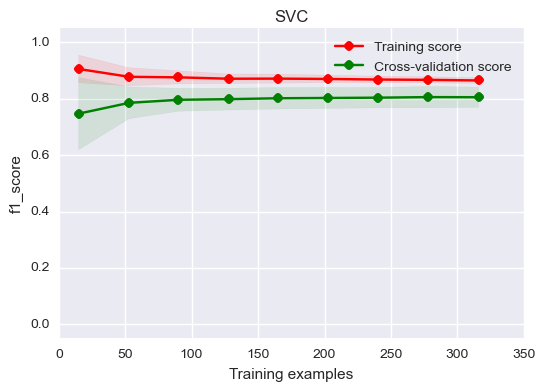

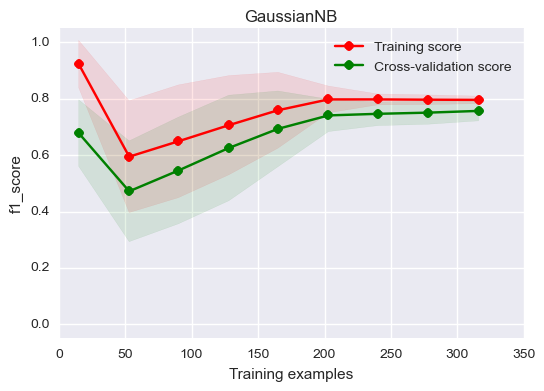

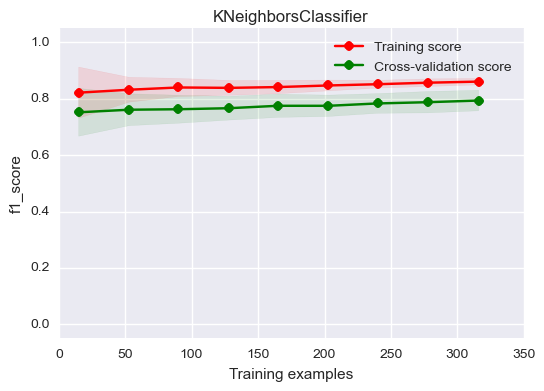

In [19]:
from sklearn.metrics import make_scorer

X, y = X_all, y_all
cv = ShuffleSplit(n_splits=100, test_size=0.2, random_state=2)
f1_scorer = make_scorer(f1_score, pos_label='yes')

for clf in [clf_A, clf_B, clf_C]:
    plot_learning_curve(clf, clf.__class__.__name__,  X, y, ylim=(-0.05,1.05), cv=cv, n_jobs=4, scoring= f1_scorer)
    plt.grid(True)   

plt.show()

## Choosing the Best Model
In this final section, you will choose from the three supervised learning models the *best* model to use on the student data. You will then perform a grid search optimization for the model over the entire training set (`X_train` and `y_train`) by tuning at least one parameter to improve upon the untuned model's F<sub>1</sub> score. 

In [9]:
# predicting all "yes" values on the test set
print "F1 score for predicting all \"yes\" on test set: {:.4f}".format(
    f1_score(y_test, ['yes']*len(y_test), pos_label='yes', average='binary'))

F1 score for predicting all "yes" on test set: 0.8125


### Question 3 - Choosing the Best Model
*Based on the experiments you performed earlier, in one to two paragraphs, explain to the board of supervisors what single model you chose as the best model. Which model is generally the most appropriate based on the available data, limited resources, cost, and performance?*

**Answer: **
The f1 score of the SVC and the KNeighborsClassifier are somewhat similar, and higher than the f1 score of the GaussianNB. On the other GaussianNB outperforms the other two classifiers in both the training and the testing time. SVC training time will increase exponentially with more data and the predicting time of the KNeighborsClassifier will also increase with more data.

GaussianNB is not powerful isn’t powerful enough to provide accurate models and it is important to note that the graduation rate is far from the goal 95%. Even when the computational time will grow if the data set is increase the model chosen is the KNeighborsClassifier because it is very hard to do better unless we make some other assumptions and performs better (F1 score for test set: 0.8143) than predicting all "yes" on test set (F1 score: 0.8125).

### Question 4 - Model in Layman's Terms
*In one to two paragraphs, explain to the board of directors in layman's terms how the final model chosen is supposed to work. Be sure that you are describing the major qualities of the model, such as how the model is trained and how the model makes a prediction. Avoid using advanced mathematical or technical jargon, such as describing equations or discussing the algorithm implementation.*

**Answer: **

The KNN model is "trained" by simply storing information about previous students who passed or failed. These "features" include info such as age, gender, absences, etc. To predict an outcome for a new student, we compare the student features with the features of those students that we have stored. The comparison returns a measure of how "similar" these students are.

We then take the "k" most similar previous students and look for whether a majority of them passed or failed ("k" is a predefined number, and the most similar students are the more accurate our prediction will be). If a majority of the nearest neighbor students passed, we predict that the student will also pass.

### Implementation: Model Tuning
Fine tune the chosen model. Use grid search (`GridSearchCV`) with at least one important parameter tuned with at least 3 different values. You will need to use the entire training set for this. In the code cell below, you will need to implement the following:
- Import [`sklearn.grid_search.GridSearchCV`](http://scikit-learn.org/0.17/modules/generated/sklearn.grid_search.GridSearchCV.html) and [`sklearn.metrics.make_scorer`](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html).
- Create a dictionary of parameters you wish to tune for the chosen model.
 - Example: `parameters = {'parameter' : [list of values]}`.
- Initialize the classifier you've chosen and store it in `clf`.
- Create the F<sub>1</sub> scoring function using `make_scorer` and store it in `f1_scorer`.
 - Set the `pos_label` parameter to the correct value!
- Perform grid search on the classifier `clf` using `f1_scorer` as the scoring method, and store it in `grid_obj`.
- Fit the grid search object to the training data (`X_train`, `y_train`), and store it in `grid_obj`.

In [21]:
print clf_C

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=5, p=2,
           weights='uniform')


In [22]:
# TODO: Import 'GridSearchCV' and 'make_scorer'
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# TODO: Create the parameters list you wish to tune
metrics = ['minkowski','euclidean','manhattan'] 
weights = ['uniform','distance'] 
numNeighbors  = np.arange(5,10)

param_grid = dict(metric=metrics,weights=weights,n_neighbors=numNeighbors)

# TODO: Initialize the classifier
clf = clf_C

# TODO: Make an f1 scoring function using 'make_scorer' 
f1_scorer = make_scorer(f1_score, pos_label='yes')

# Stratified K-Folds cross-validator
skf = StratifiedKFold(random_state=2, shuffle=True)
cv = skf

# TODO: Perform grid search on the classifier using the f1_scorer as the scoring method
grid_obj = GridSearchCV(clf, param_grid, cv=cv, scoring=f1_scorer)

# TODO: Fit the grid search object to the training data and find the optimal parameters
grid_obj = grid_obj.fit(X_train, y_train)

# Get the estimator
clf = grid_obj.best_estimator_

# Report the final F1 score for training and testing after parameter tuning
print "Tuned model has a training F1 score of {:.4f}.".format(predict_labels(clf, X_train, y_train))
print "Tuned model has a testing F1 score of {:.4f}.".format(predict_labels(clf, X_test, y_test))

Made predictions in 0.0160 seconds.
Tuned model has a training F1 score of 0.8337.
Made predictions in 0.0064 seconds.
Tuned model has a testing F1 score of 0.8227.


In [23]:
# best parameters from GridSearchCV
print grid_obj.best_params_

{'n_neighbors': 9, 'metric': 'minkowski', 'weights': 'uniform'}


## Normalizing the data, from reviewer

In [12]:
# TODO: Import 'GridSearchCV' and 'make_scorer'
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# standardizing the data to even out the possibly different scales of the features
from sklearn.preprocessing import normalize
X_train = normalize(X_train)
X_test = normalize(X_test)

# TODO: Create the parameters list you wish to tune
metrics = ['euclidean', 'manhattan', 'chebyshev', 'minkowski'] 
weights = ['uniform','distance'] 
numNeighbors  = [2, 4, 8, 16, 32]
leaf_sizes = [5, 10, 20, 30]
p = [1, 2, 3]

param_grid = dict(metric=metrics,weights=weights,n_neighbors=numNeighbors, 
                  leaf_size=leaf_sizes, p=p)

# TODO: Initialize the classifier
clf = clf_C

# TODO: Make an f1 scoring function using 'make_scorer' 
f1_scorer = make_scorer(f1_score, pos_label='yes')

# Stratified K-Folds cross-validator
skf = StratifiedKFold(n_splits=5, random_state=2, shuffle=True)
cv = skf

# TODO: Perform grid search on the classifier using the f1_scorer as the scoring method
grid_obj = GridSearchCV(clf, param_grid, cv=cv, scoring=f1_scorer, verbose=1,
                        n_jobs=-1, pre_dispatch='2*n_jobs')

# TODO: Fit the grid search object to the training data and find the optimal parameters
grid_obj = grid_obj.fit(X_train, y_train)

# Get the estimator
clf = grid_obj.best_estimator_

# Report the final F1 score for training and testing after parameter tuning
print "Tuned model has a training F1 score of {:.4f}.".format(predict_labels(clf, X_train, y_train))
print "Tuned model has a testing F1 score of {:.4f}.".format(predict_labels(clf, X_test, y_test))

Fitting 5 folds for each of 480 candidates, totalling 2400 fits


[Parallel(n_jobs=-1)]: Done 220 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done 1120 tasks      | elapsed:   33.8s


Made predictions in 0.0422 seconds.
Tuned model has a training F1 score of 1.0000.
Made predictions in 0.0147 seconds.
Tuned model has a testing F1 score of 0.8280.


[Parallel(n_jobs=-1)]: Done 2400 out of 2400 | elapsed:  1.3min finished


In [35]:
from sklearn.metrics import classification_report\

# Pretty display for notebooks
%matplotlib inline

y_true, y_pred = y_test, clf.predict(X_test)
print(classification_report(y_true, y_pred))

             precision    recall  f1-score   support

         no       1.00      0.10      0.18        30
        yes       0.71      1.00      0.83        65

avg / total       0.80      0.72      0.62        95



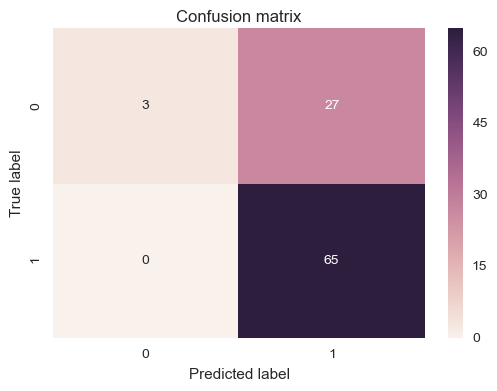

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = clf.predict(X_test)
y_true = y_test

conf_matrix = confusion_matrix(y_true, y_pred)

# seaborn heatmap for confusion matrix
ax = sns.heatmap(conf_matrix, annot= True, xticklabels=True , yticklabels=True)
plt.title('Confusion matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')


### Question 5 - Final F<sub>1</sub> Score
*What is the final model's F<sub>1</sub> score for training and testing? How does that score compare to the untuned model?*

**Answer: **
The final model's F1 score for training and testing are:

* Tuned model has a training F1 score of 0.8337.

* Tuned model has a testing F1 score of 0.8227.

The untuned model's F1 score for training and testing are

* F1 score for training set: 0.8558.

* F1 score for test set: 0.8143.

With the model tuned the F1 score in the testing set is now higher and converging to the other.